### Dataset from NOAA Operational Forecast System (OFS)  (from March 27, 2025, to March 29, 2025.)
### Data used is from the **West Coast Operational Forecast System (WCOFS)**
#### https://registry.opendata.aws/noaa-ofs/

In [13]:
import xarray as xr
from xarray import open_dataset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from scipy import signal

In [14]:
ds = open_dataset(r'./67ebd40a-2068-18945.nc')
ds

<xarray.Dataset> Size: 186MB
Dimensions:          (nply: 4, two: 2, tracer: 2, boundary: 4, eta_rho: 1016,
                      xi_rho: 347, eta_u: 1016, xi_u: 346, eta_v: 1015,
                      xi_v: 347, eta_psi: 1015, xi_psi: 346, ocean_time: 49)
Coordinates:
    lon_rho          (eta_rho, xi_rho) float64 3MB ...
    lat_rho          (eta_rho, xi_rho) float64 3MB ...
    lon_u            (eta_u, xi_u) float64 3MB ...
    lat_u            (eta_u, xi_u) float64 3MB ...
    lon_v            (eta_v, xi_v) float64 3MB ...
    lat_v            (eta_v, xi_v) float64 3MB ...
    lon_psi          (eta_psi, xi_psi) float64 3MB ...
    lat_psi          (eta_psi, xi_psi) float64 3MB ...
  * ocean_time       (ocean_time) datetime64[ns] 392B 2025-03-27 ... 2025-03-29
Dimensions without coordinates: nply, two, tracer, boundary, eta_rho, xi_rho,
                                eta_u, xi_u, eta_v, xi_v, eta_psi, xi_psi
Data variables: (12/52)
    x                (nply) float64 32B ...
    y                (nply) float64 32B ...
    requested_times  (two) |S26 52B ...
    ntimes           int32 4B ...
    ndtfast          int32 4B ...
    dt               float64 8B ...
    ...               ...
    mask_u           (eta_u, xi_u) float64 3MB ...
    mask_v           (eta_v, xi_v) float64 3MB ...
    mask_psi         (eta_psi, xi_psi) float64 3MB ...
    nf_type          (ocean_time) int32 196B ...
    Times            (ocean_time) |S26 1kB ...
    zeta             (ocean_time, eta_rho, xi_rho) float64 138MB ...
Attributes: (12/28)
    note:              Output from CO-OPS subsetting/Aggregation tool
    user_email:        anandrm@outlook.com
    format:            netCDF-4/HDF5 file
    Conventions:       CF-1.4, SGRID-0.3
    type:              ROMS/TOMS quicksave file
    title:             wcofs nowcast RUN in operational mode
    ...                ...
    compiler_command:  /opt/cray/pe/craype/2.7.17/bin/ftn
    compiler_flags:    -fp-model precise -ip -O3
    tiling:            008x060
    history:           ROMS/TOMS, Version 4.2, Thursday - March 27, 2025 -  3...
    ana_file:          ROMS/Functionals/ana_btflux.h
    CPP_options:       mode, ADD_FSOBC, ADD_M2OBC, ANA_BSFLUX, ANA_BTFLUX, AS...

In [15]:
print(ds.variables.keys())


KeysView(Frozen({'x': <xarray.Variable (nply: 4)> Size: 32B
[4 values with dtype=float64]
Attributes:
    standard_name:  longitude
    long_name:      longitude of the polygon vertices
    units:          degree_east, 'y': <xarray.Variable (nply: 4)> Size: 32B
[4 values with dtype=float64]
Attributes:
    standard_name:  latitude
    long_name:      latitude of the polygon vertices
    units:          degree_north, 'requested_times': <xarray.Variable (two: 2)> Size: 52B
[2 values with dtype=|S26]
Attributes:
    long_name:   requested time period
    time_zone:   UTC
    start_date:  2025-03-27T00:00
    end_date:    2025-03-29T00:00, 'ntimes': <xarray.Variable ()> Size: 4B
[1 values with dtype=int32]
Attributes:
    long_name:  number of long time-steps, 'ndtfast': <xarray.Variable ()> Size: 4B
[1 values with dtype=int32]
Attributes:
    long_name:  number of short time-steps, 'dt': <xarray.Variable ()> Size: 8B
[1 values with dtype=float64]
Attributes:
    long_name:  size of long t

In [16]:
def sea_level_plots(ds, time_index=0):
    """
    Side-by-side comparison of the original and enhanced sea level plots.
    The function visualizes the sea surface height (zeta) at a specific time index from the dataset.
    Two Plots:
    1. The original plot using the "viridis" colormap to show the raw sea level height data.
    2. An enhanced plot using the "RdBu_r" colormap with a fixed color range to highlight variations more clearly.
    """
    zeta = ds.zeta.isel(ocean_time=time_index)
    lon = ds.lon_rho
    lat = ds.lat_rho
    time = pd.to_datetime(ds.ocean_time[time_index].values)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8), 
                                  subplot_kw={'projection': ccrs.PlateCarree()})
    
    # Original plot
    p1 = ax1.pcolormesh(lon, lat, zeta, cmap="viridis", shading="auto")
    ax1.add_feature(cfeature.COASTLINE)
    ax1.set_title(f"Original: Sea Level Height (zeta) on {str(time)}")
    cbar1 = plt.colorbar(p1, ax=ax1, orientation="vertical")
    cbar1.set_label("Sea Level Height (m)")
    
    # Enhanced plot with adjusted color range
    vmin, vmax = -0.5, 0.5
    p2 = ax2.pcolormesh(lon, lat, zeta, cmap="RdBu_r", vmin=vmin, vmax=vmax, shading="auto")
    ax2.add_feature(cfeature.COASTLINE, linewidth=0.8)
    ax2.add_feature(cfeature.BORDERS, linestyle=':')
    ax2.add_feature(cfeature.STATES, linestyle=':')
    gl = ax2.gridlines(draw_labels=True, linewidth=0.5, alpha=0.5, linestyle='--')
    gl.top_labels = False
    gl.right_labels = False
    ax2.set_title(f"Enhanced: Sea Surface Height on {time.strftime('%Y-%m-%d %H:%M')} UTC", fontsize=12)
    cbar2 = plt.colorbar(p2, ax=ax2, orientation="vertical", pad=0.02)
    cbar2.set_label("Sea Level Height (m)", fontsize=12)
    
    lon_min, lon_max = lon.min().item(), lon.max().item()
    lat_min, lat_max = lat.min().item(), lat.max().item()
    for ax in [ax1, ax2]:
        ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
    
    plt.tight_layout()
    return fig


In [17]:
def find_nearest_point(lat, lon, lat_point, lon_point):
    """
    Parameters:
    lat (xarray.DataArray): Latitude values of the grid.
    lon (xarray.DataArray): Longitude values of the grid.
    lat_point (float): Latitude of the target location.
    lon_point (float): Longitude of the target location.
    
    Returns:
    tuple: Indices (eta_idx, xi_idx) of the nearest grid point in the latitude-longitude grid.
    """
    # Calculate the absolute difference between target and all points
    # This function is needed to map a specific latitude and longitude to the nearest grid point
    # in the dataset. It ensures that we can extract data from the closest grid cell to the
    # desired location.
    dist = np.sqrt((lat - lat_point)**2 + (lon - lon_point)**2)
    idx = np.unravel_index(dist.argmin(), dist.shape)
    return idx

def plot_time_series(ds, lat_point, lon_point):
    """
    Parameters:
    ds (xarray.Dataset): dataset
    lat_point (float): Latitude of the target location.
    lon_point (float): Longitude of the target location.
    
    Returns:
    matplotlib.figure
    """
    idx = find_nearest_point(ds.lat_rho, ds.lon_rho, lat_point, lon_point)  # Finding the nearest grid point to our desired location
    eta_idx, xi_idx = idx
    
    sea_level = ds.zeta.isel(eta_rho=eta_idx, xi_rho=xi_idx) # isel is used for index-based selection
    times = pd.to_datetime(ds.ocean_time.values)
    
    actual_lat = float(ds.lat_rho[eta_idx, xi_idx].values)
    actual_lon = float(ds.lon_rho[eta_idx, xi_idx].values)
    
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(times, sea_level, 'b-', linewidth=2)
    ax.set_title(f"Sea Level Time Series at {actual_lat:.2f}°N, {actual_lon:.2f}°E")
    ax.set_xlabel("Time (UTC)")
    ax.set_ylabel("Sea Level (m)")
    ax.grid(True)
    ax.set_xlim(times.min(), times.max())
    

    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
    plt.xticks(rotation=45)
    
    return fig

In [18]:
def plot_sea_level_change(ds, time_index1=0, time_index2=24):
    zeta1 = ds.zeta.isel(ocean_time=time_index1)  # Initial time point
    zeta2 = ds.zeta.isel(ocean_time=time_index2)  # Final time point  
    
    delta_zeta = zeta2 - zeta1
    
    time1 = pd.to_datetime(ds.ocean_time[time_index1].values)
    time2 = pd.to_datetime(ds.ocean_time[time_index2].values)

    lon = ds.lon_rho
    lat = ds.lat_rho
    
    fig, ax = plt.subplots(figsize=(12, 8), subplot_kw={'projection': ccrs.PlateCarree()})
    
    vmax = max(0.2, abs(delta_zeta).max().item() * 0.8)
    vmin = -vmax 
    p = ax.pcolormesh(lon, lat, delta_zeta, cmap="RdBu_r", vmin=vmin, vmax=vmax, shading="auto")  
    

    ax.add_feature(cfeature.COASTLINE, linewidth=0.8) # Coastline feature (can be removed if not needed)
    ax.add_feature(cfeature.BORDERS, linestyle=':')   # Borders feature   (can be removed if not needed)

    gl = ax.gridlines(draw_labels=True, linewidth=0.5, alpha=0.5, linestyle='--')
    gl.top_labels = False
    gl.right_labels = False

    period = (time2 - time1).total_seconds() / 3600
    ax.set_title(f"Sea Level Change over {period:.0f} hours\n({time1.strftime('%Y-%m-%d %H:%M')} to {time2.strftime('%Y-%m-%d %H:%M')})", fontsize=14)
    
    cbar = plt.colorbar(p, ax=ax, orientation="vertical", pad=0.02)
    cbar.set_label("Sea Level Change (m)", fontsize=12)

    lon_min, lon_max = lon.min().item(), lon.max().item()
    lat_min, lat_max = lat.min().item(), lat.max().item()
    ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
    
    plt.tight_layout()
    return fig

In [19]:
def analyze_tides(ds, lat_point, lon_point):
    """
    Perform harmonic analysis to identify tidal patterns at a specific location.
    This function extracts sea level data at a specified location, detrends it to remove linear trends, and 
    applies a Fast Fourier Transform (FFT) to analyze the frequency spectrum.

    Parameters:
    ds (xarray.Dataset): The dataset containing sea level data.
    lat_point (float): Latitude of the target location.
    lon_point (float): Longitude of the target location.

    Returns:
    matplotlib.figure
    """
    
    idx = find_nearest_point(ds.lat_rho, ds.lon_rho, lat_point, lon_point) # Find the nearest grid point to the specified location in order to extract the sea level data of that point
    eta_idx, xi_idx = idx
    
    # Extract sea level time series at the nearest grid point
    sea_level = ds.zeta.isel(eta_rho=eta_idx, xi_rho=xi_idx) # isel is used for index-based selection at the nearest grid point
    times = pd.to_datetime(ds.ocean_time.values)
    
    actual_lat = float(ds.lat_rho[eta_idx, xi_idx].values)
    actual_lon = float(ds.lon_rho[eta_idx, xi_idx].values)
    
    sea_level_values = sea_level.values
    
    detrended = signal.detrend(sea_level_values)  # removing any linear trends from the data
    
    fft_result = np.fft.rfft(detrended) # Fast Fourier Transform (FFT) to analyze the frequency spectrum
    fft_freq = np.fft.rfftfreq(len(detrended), d=1)  # 1 Hour steps as specified from NOA OFS dataset
    
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))
    
    ax1.plot(times, sea_level_values, 'b-', linewidth=2, label='Original')
    ax1.plot(times, detrended, 'r-', linewidth=1, alpha=0.7, label='Detrended')
    ax1.set_title(f"Sea Level Time Series at {actual_lat:.2f}°N, {actual_lon:.2f}°E")
    ax1.set_xlabel("Time (UTC)")
    ax1.set_ylabel("Sea Level (m)")
    ax1.grid(True)
    ax1.legend()
    
    
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
    ax1.tick_params(axis='x', rotation=45)
    

    periods = 1 / fft_freq  # Convert frequency to periods in hours
    valid_idx = (periods > 0) & (periods < 48)  # taking the periods between 0 to 48 hours
    
    ax2.plot(periods[valid_idx], np.abs(fft_result)[valid_idx], 'g-')
    ax2.set_title("Frequency Spectrum")
    ax2.set_xlabel("Period (hours)")
    ax2.set_ylabel("Amplitude")
    ax2.grid(True)
    
    # Common tidal periods (in hours) for reference
    tidal_periods = {
        "M2 (Semi-diurnal)": 12.42,
        "K1 (Diurnal)": 23.93,
        "O1 (Diurnal)": 25.82,
        "S2 (Semi-diurnal)": 12.00
    }
    
    for name, period in tidal_periods.items():
        if period < 48:  # Only show if within the plot range
            ax2.axvline(x=period, linestyle='--', alpha=0.7, color='r')
            ax2.text(period, ax2.get_ylim()[1]*0.9, name, rotation=90, 
                     verticalalignment='top', alpha=0.7)
    
    plt.tight_layout()
    return fig

C:\Users\hp\AppData\Local\Temp\ipykernel_24144\3124118213.py:49: RuntimeWarning: divide by zero encountered in divide
  periods = 1 / fft_freq  # Convert frequency to periods in hours


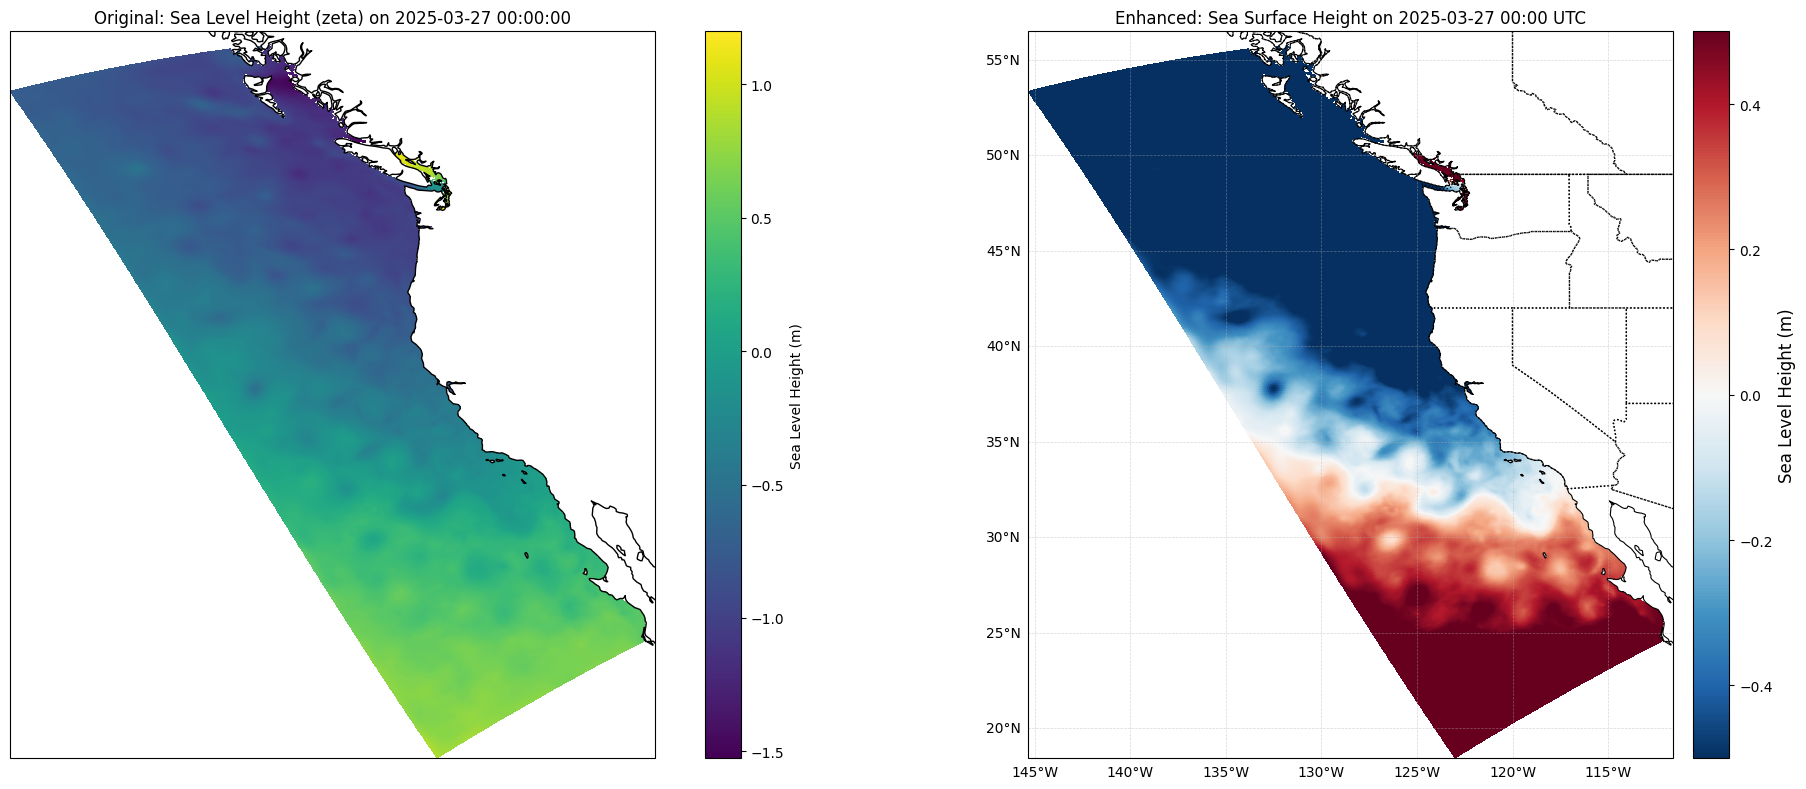

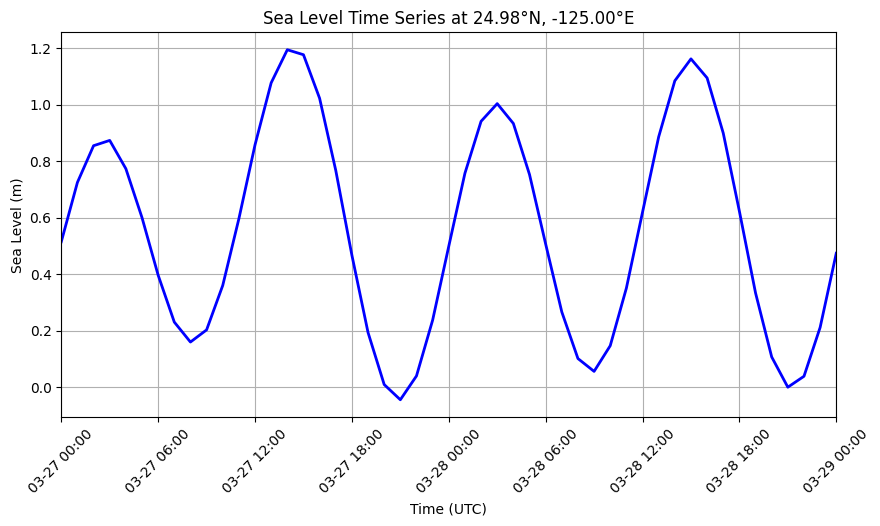

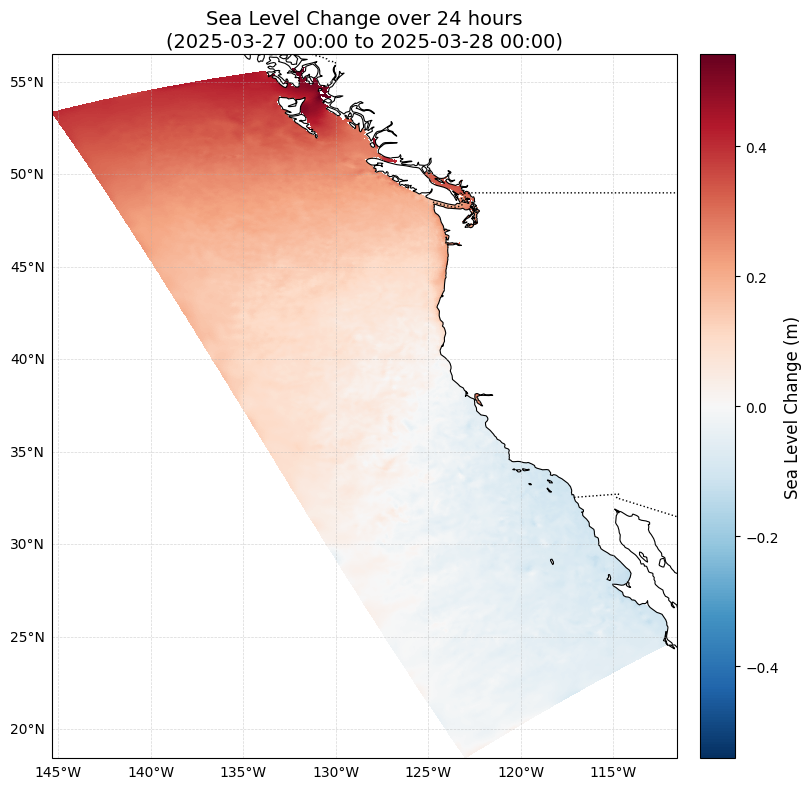

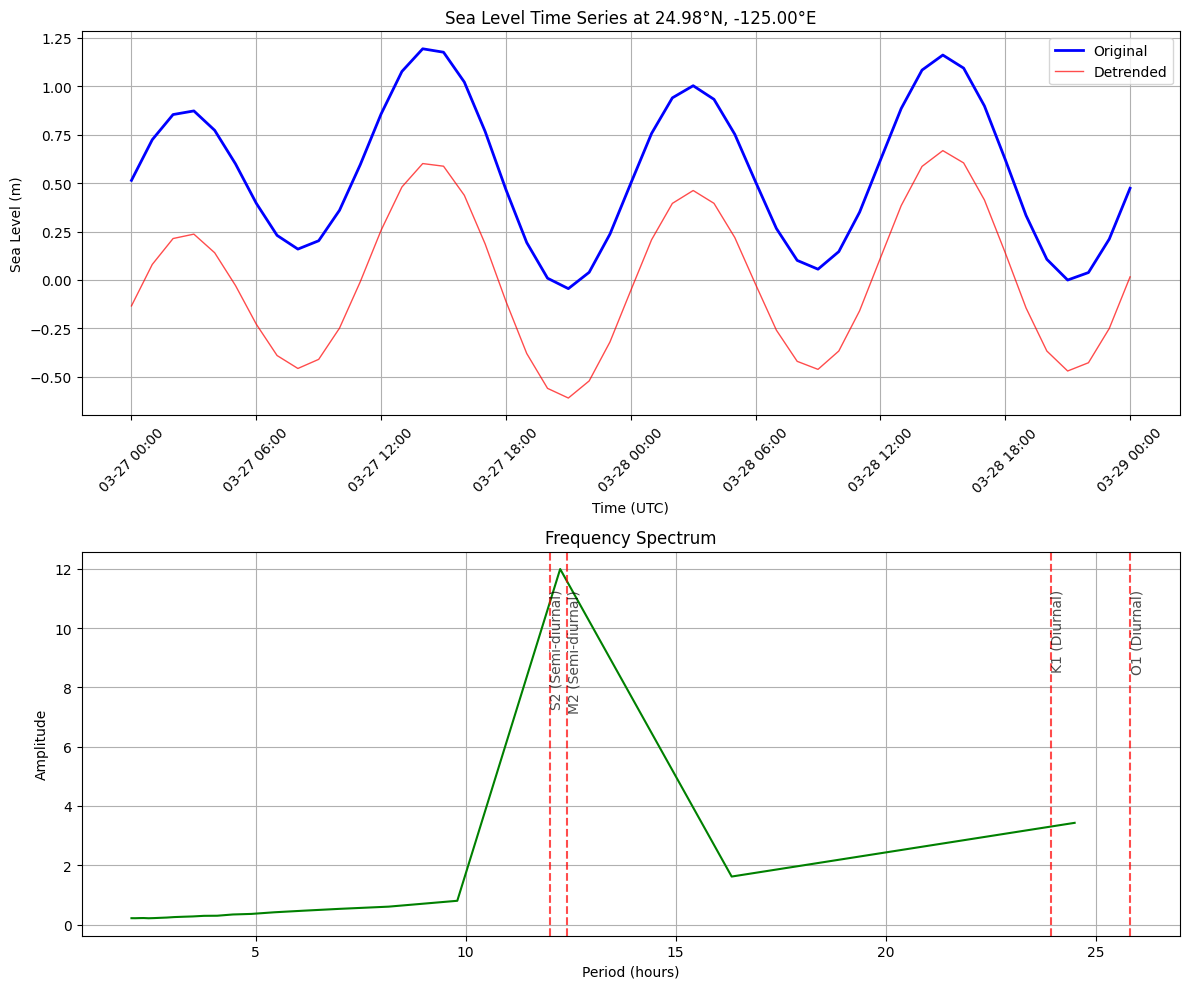

In [20]:
def main(ds):
    sea_level_plots(ds, time_index=0)
    plot_time_series(ds, lat_point=25, lon_point=-125)
    plot_sea_level_change(ds, time_index1=0, time_index2=24)
    analyze_tides(ds, lat_point=25, lon_point=-125)

if __name__ == "__main__":
    # ds = open_dataset('./67ebd40a-2068-18945.nc')
    main(ds)